In [ ]:
# Cell 0  ─── install Ultralytics (YOLO v8 wrapper)
!pip install --quiet ultralytics
# same version we used in the paper


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 849.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 25.4 MB/s eta 0:00:00


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")


✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Input preprocessed dataset
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
split_base = "/content/EuroSAT_full_split"
train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")

# Create folders
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Get class names
classes = sorted(os.listdir(source_dir))

# Split images for each class
for cls in tqdm(classes, desc="Splitting Classes"):
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Split (80% train, 20% val)
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # Create class folders
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)

    # Copy train images
    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))

    # Copy val images
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))

print("✅ All images split and saved to:", split_base)


Splitting Classes: 100%|██████████| 10/10 [17:31<00:00, 105.16s/it]

✅ All images split and saved to: /content/EuroSAT_full_split


In [ ]:
import os
from PIL import Image
from tqdm import tqdm

# Input and Output paths
input_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
output_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_resized_300"

# Resize size
resize_size = (300, 300)

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Loop through classes
classes = [cls for cls in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, cls))]

for cls in classes:
    input_cls_path = os.path.join(input_dir, cls)
    output_cls_path = os.path.join(output_dir, cls)
    os.makedirs(output_cls_path, exist_ok=True)

    image_files = [f for f in os.listdir(input_cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_file in tqdm(image_files, desc=f"Resizing {cls}"):
        input_path = os.path.join(input_cls_path, img_file)
        output_path = os.path.join(output_cls_path, img_file)

        try:
            img = Image.open(input_path).convert("RGB")
            img_resized = img.resize(resize_size, Image.BICUBIC)
            img_resized.save(output_path)
        except Exception as e:
            print(f"❌ Error resizing {input_path}: {e}")

print("\n✅ All images resized to 300x300 and saved to:", output_dir)


Resizing AnnualCrop: 100%|██████████| 3010/3010 [01:39<00:00, 30.28it/s]


✅ All images resized to 300x300 and saved to: /content/drive/MyDrive/project/basepaper/EuroSAT_resized_300


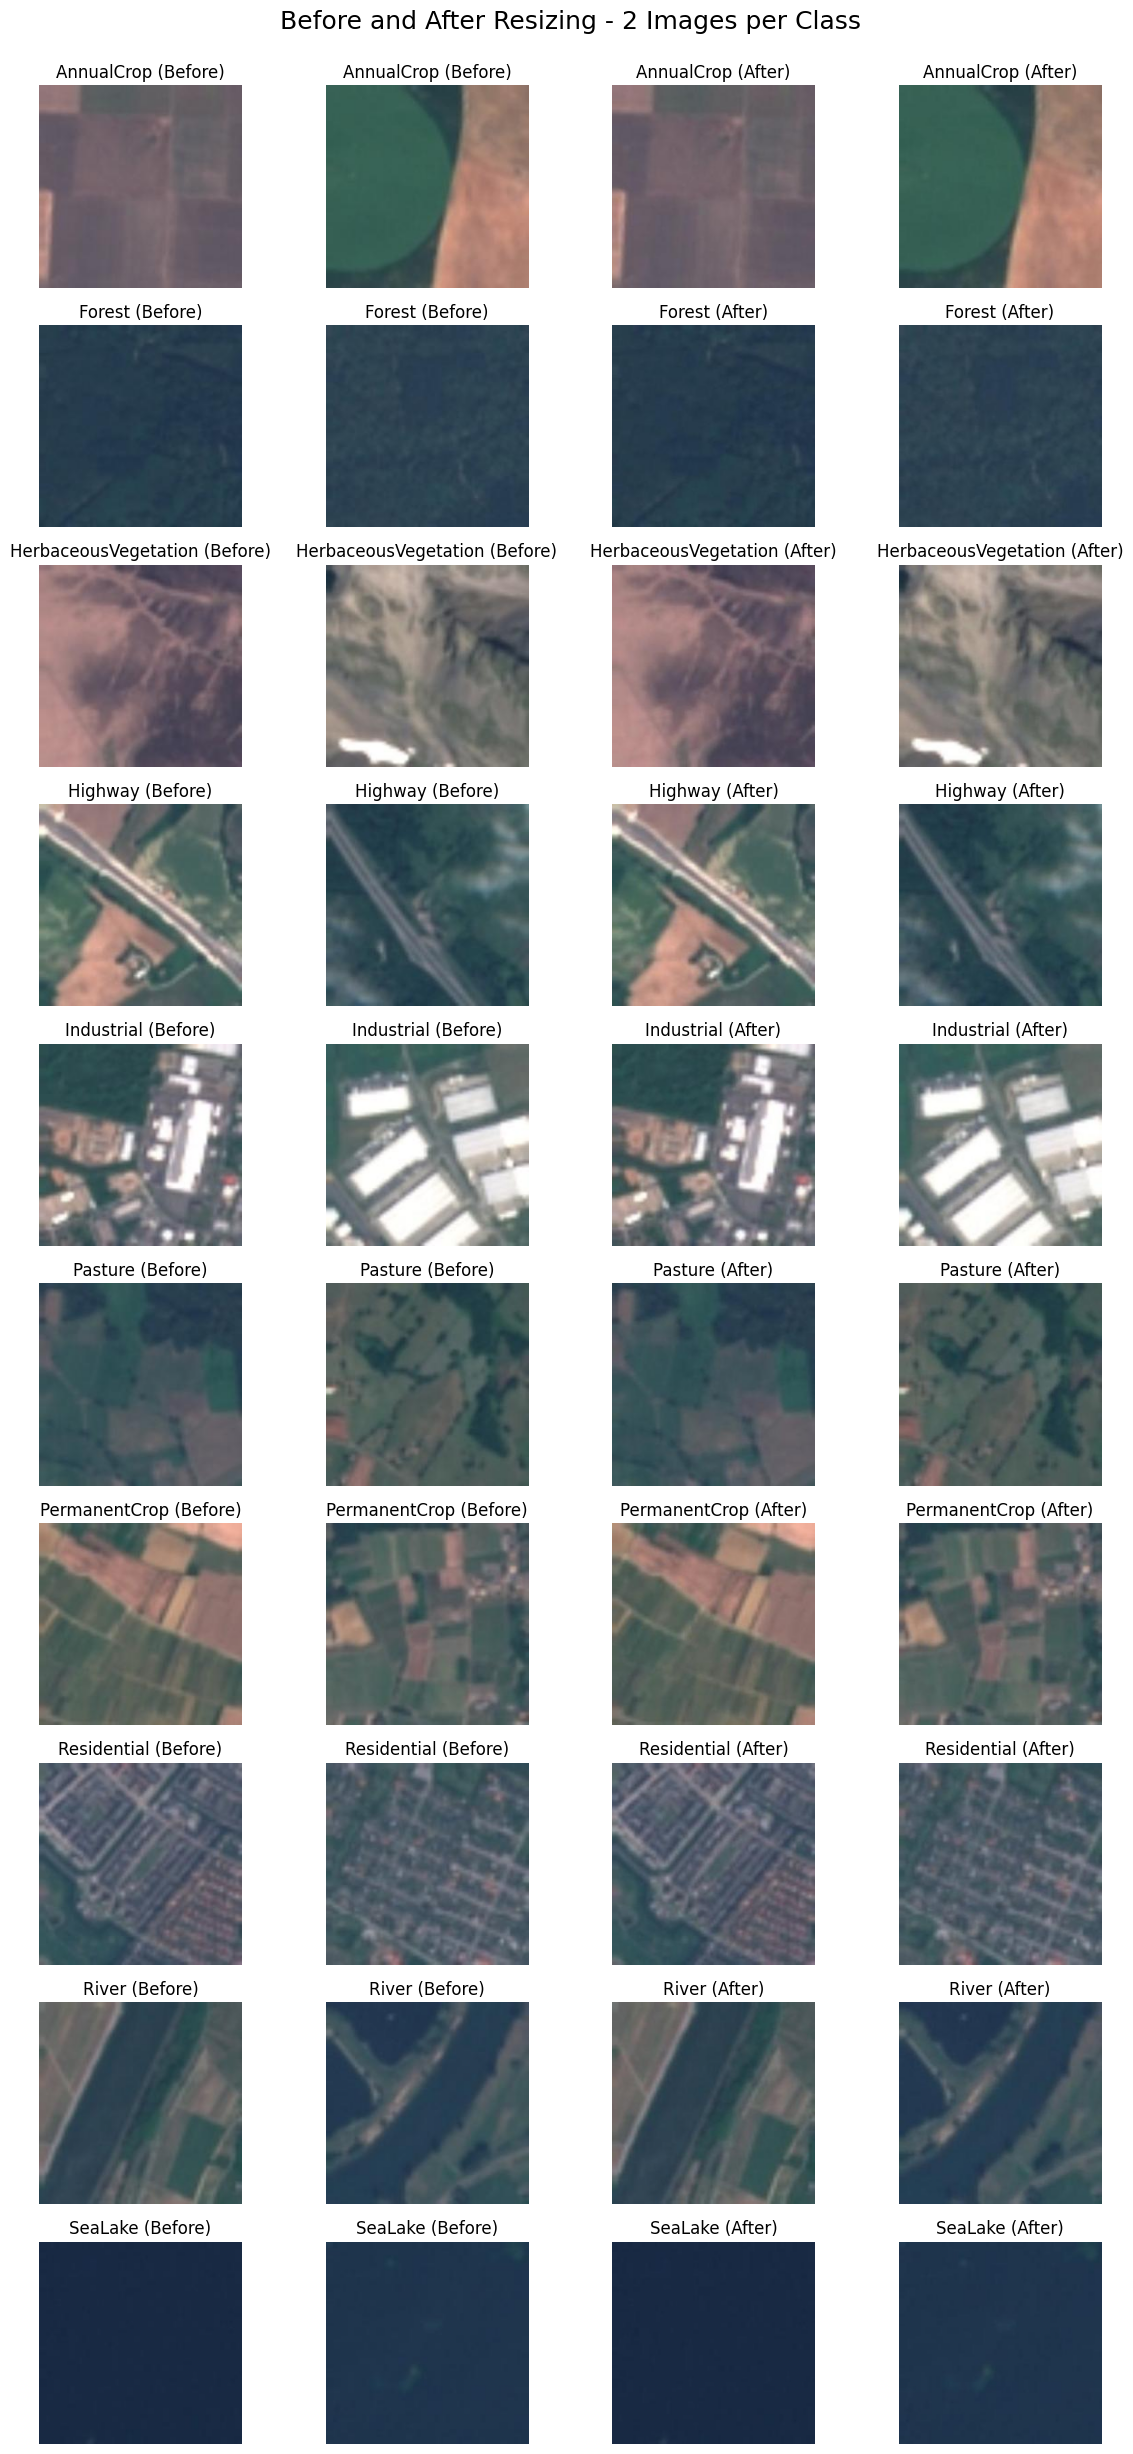

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Paths
before_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
after_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_resized_300"

# Get class names
classes = sorted(os.listdir(before_dir))

# Plotting
fig, axes = plt.subplots(len(classes), 4, figsize=(12, 25))
fig.suptitle("Before and After Resizing - 2 Images per Class", fontsize=18)

for row, cls in enumerate(classes):
    # Get image names
    before_images = sorted([f for f in os.listdir(os.path.join(before_dir, cls)) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])[:2]
    after_images = before_images  # Assuming same names used

    # Load before images
    for col in range(2):
        img_path = os.path.join(before_dir, cls, before_images[col])
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{cls} (Before)")
        axes[row, col].axis('off')

    # Load after images
    for col in range(2):
        img_path = os.path.join(after_dir, cls, after_images[col])
        img = Image.open(img_path)
        axes[row, col + 2].imshow(img)
        axes[row, col + 2].set_title(f"{cls} (After)")
        axes[row, col + 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# Input resized image path
input_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_resized_300"
output_base = "/content/EuroSAT_500_split"  # This will have /train and /val subfolders

# Split ratio
train_ratio = 0.8

# Create train and val folders
train_dir = os.path.join(output_base, "train")
val_dir = os.path.join(output_base, "val")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Loop through each class and split images
classes = sorted([cls for cls in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, cls))])

for cls in tqdm(classes, desc="Splitting into train/val"):
    class_input_path = os.path.join(input_dir, cls)
    images = [f for f in os.listdir(class_input_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.shuffle(images)
    split_idx = int(train_ratio * len(images))
    train_images = images[:split_idx]
    val_images = images[split_idx:]

    # Create output class folders
    cls_train_path = os.path.join(train_dir, cls)
    cls_val_path = os.path.join(val_dir, cls)
    os.makedirs(cls_train_path, exist_ok=True)
    os.makedirs(cls_val_path, exist_ok=True)

    # Copy images
    for img in train_images:
        shutil.copy(os.path.join(class_input_path, img), os.path.join(cls_train_path, img))
    for img in val_images:
        shutil.copy(os.path.join(class_input_path, img), os.path.join(cls_val_path, img))

print("\n✅ Dataset successfully split into train and val folders at:", output_base)


Splitting into train/val: 100%|██████████| 10/10 [08:51<00:00, 53.12s/it]


✅ Dataset successfully split into train and val folders at: /content/EuroSAT_500_split


In [3]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm


In [4]:
# Paths
data_dir = "/content/EuroSAT_500_split"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")

# Config
batch_size = 32
num_epochs = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms (EfficientNet-B3 expects 300x300)
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [7]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Number of classes in your dataset
num_classes = 10  # Update if needed

# Load pretrained EfficientNet-B3
weights = EfficientNet_B3_Weights.DEFAULT
model = efficientnet_b3(weights=weights)

# Modify the classifier for 10-class output
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# Move model to device (GPU or CPU)
model = model.to(device)


In [9]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torch.utils.data import DataLoader
from tqdm import tqdm

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters
num_classes = 10
img_size = 300
batch_size = 16
num_epochs = 10


In [17]:
import os

print("train_dir exists:", os.path.exists('/content/EuroSAT_500_split/train'))
print("val_dir exists:", os.path.exists('/content/EuroSAT_500_split/val'))


train_dir exists: False
val_dir exists: False


In [18]:
import os
import shutil
import random
from tqdm import tqdm

# Input path: resized 300x300 images (already preprocessed)
input_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_resized_300"

# Output base directory inside Colab
output_base = "/content/EuroSAT_500_split"
train_dir = os.path.join(output_base, "train")
val_dir = os.path.join(output_base, "val")

# Create output folders
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# List of class names (folders)
classes = sorted([cls for cls in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, cls))])

# Split ratio
train_ratio = 0.8

# Split and copy images
for cls in tqdm(classes, desc="🔁 Splitting into train/val"):
    class_input_path = os.path.join(input_dir, cls)
    images = [f for f in os.listdir(class_input_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.shuffle(images)
    split_idx = int(train_ratio * len(images))
    train_images = images[:split_idx]
    val_images = images[split_idx:]

    # Create class subfolders
    cls_train_path = os.path.join(train_dir, cls)
    cls_val_path = os.path.join(val_dir, cls)
    os.makedirs(cls_train_path, exist_ok=True)
    os.makedirs(cls_val_path, exist_ok=True)

    # Copy images
    for img in train_images:
        shutil.copy(os.path.join(class_input_path, img), os.path.join(cls_train_path, img))
    for img in val_images:
        shutil.copy(os.path.join(class_input_path, img), os.path.join(cls_val_path, img))

print("✅ Dataset successfully split.")
print("📂 Train path:", train_dir)
print("📂 Val path  :", val_dir)


🔁 Splitting into train/val: 100%|██████████| 10/10 [11:58<00:00, 71.81s/it]

✅ Dataset successfully split.
📂 Train path: /content/EuroSAT_500_split/train
📂 Val path  : /content/EuroSAT_500_split/val


In [19]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Set image size for EfficientNet-B3
img_size = 300
batch_size = 16

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Paths
train_dir = "/content/EuroSAT_500_split/train"
val_dir = "/content/EuroSAT_500_split/val"

# Datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("✅ DataLoaders created.")
print("Classes:", train_dataset.classes)


✅ DataLoaders created.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [20]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 10  # Adjust if your dataset has different class count

# Load model
weights = EfficientNet_B3_Weights.DEFAULT
model = efficientnet_b3(weights=weights)

# Modify classifier for your dataset
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# Move to GPU/CPU
model = model.to(device)


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [22]:
import copy

best_val_acc = 0.0
train_loss_history = []
val_loss_history = []
val_acc_history = []

print("🔁 Training Started...\n")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Validation
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)
    val_acc = 100 * correct / total
    val_acc_history.append(val_acc)

    print(f"\n📊 Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_model.pth")
        print("💾 Best model saved!")

print("\n✅ Training completed.")


🔁 Training Started...



Epoch 1/10 [Training]:   5%|▌         | 72/1358 [15:57<4:45:01, 13.30s/it]


KeyboardInterrupt: 